In [11]:
!conda install pandas -y

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
    current version: 25.11.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda




Learned Weight (Slope): 13.2619
Learned Bias (Intercept): 24.7738


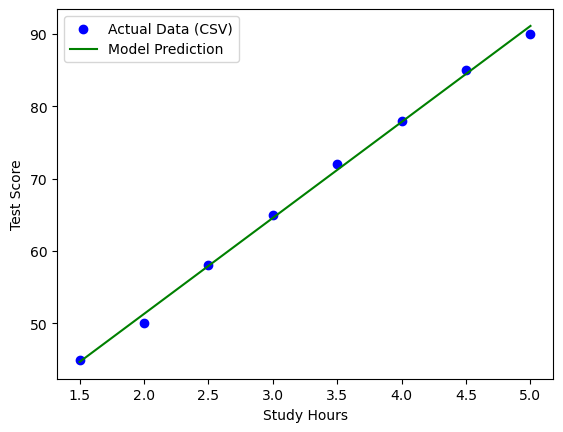

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class PureLinearRegression:
    def __init__(self):
        self.bias = None
        self.weights = None
        
    def fit(self, X, y):
        """Calculates the exact line of best fit using the Normal Equation."""
        
        X_b = np.c_[np.ones((len(X), 1)), X]
        
        # The Normal Equation
        theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        
        # Extract the bias and weights
        self.bias = theta_best[0]
        self.weights = theta_best[1:]
        
    def predict(self, X):
        """Uses the calculated weights and bias to make new predictions."""
        if self.bias is None or self.weights is None:
            raise ValueError("Model has not been trained yet. Call fit() first.")
        
        return X.dot(self.weights) + self.bias


df = pd.read_csv('data.csv')


X_data = df[['study_hours']].values 
y_data = df['test_score'].values

model = PureLinearRegression()
model.fit(X_data, y_data)

print(f"Learned Weight (Slope): {model.weights[0]:.4f}")
print(f"Learned Bias (Intercept): {model.bias:.4f}")

predictions = model.predict(X_data)

plt.scatter(X_data, y_data, color='blue', label='Actual Data (CSV)')
plt.plot(X_data, predictions, color='green', label='Model Prediction')
plt.xlabel('Study Hours')
plt.ylabel('Test Score')
plt.legend()
plt.show()